# Exercise 4.A Introduction to Linear Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1

### Running a sample script

In [3]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [4]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [5]:
y_pred = model.predict(X_test)

print('Actual scores:   ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:    [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [6]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


What the R score is telling us is how close to perfect explaination of variations the data offers. The closer to 1, the closer to perfect, while closer to 0, means that the variation is unexplained.

C:\Users\kevintran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


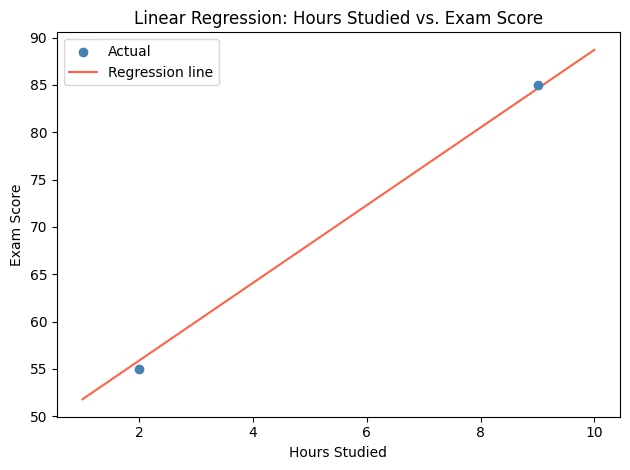

In [7]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)

# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points are pretty close to the regression line. 

## Lab 2

### Building your own model

In [9]:
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [15]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print(X2.shape)
print(y2.shape)


(20, 1)
(20,)


In [17]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [38]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
print('Model trained successfully.')

Model trained successfully.


In [ ]:
print(f'\nSlope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')
# For each addtional $1 spent, the predicted, the predict monthly revenue increases by $1.96


Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [25]:
y2_pred = model2.predict(X2_test)

print('Actual scores: ', list(y2_test))
print('Predicted scores:', list(y2_pred.round(2)))

Actual scores:  [4200, 21500, 19400, 5100]
Predicted scores: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [24]:
r_squared = model2.score(X2_test, y2_test)
print(f'R² score: {r_squared:.2f}')

R² score: 1.00


The model appears to be a good fit. 100% of the varaition in revenue is explained by ad spend.

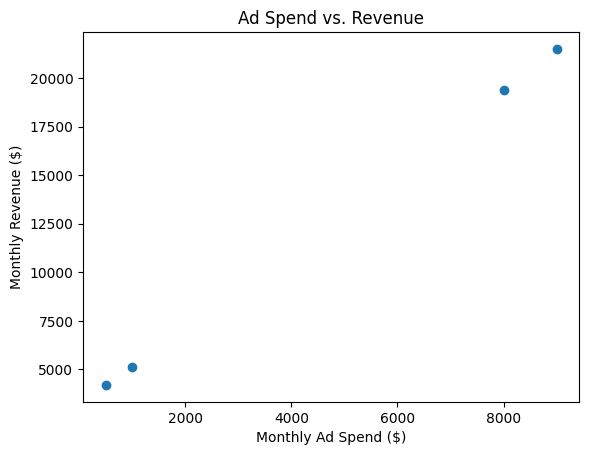

In [26]:
plt.scatter(X2_test, y2_test)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.show()

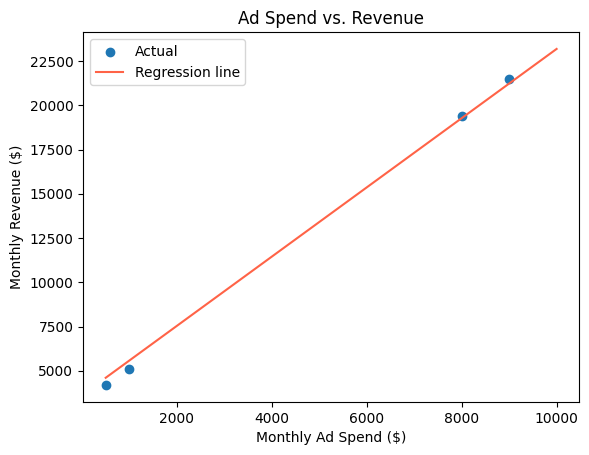

In [41]:
plt.scatter(X2_test, y2_test, label='Actual')

plt.plot(X2, model2.predict(X2), color='tomato', label='Regression line')

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.show()

The regression line does not 100% fit the actual points. The R score was a 1, but the visuals say otherwise.